In [ ]:
import spacy
import pandas as pd
import spacy.lang.yo as yo
from spacy.lang.yo.stop_words import STOP_WORDS as yor_sw
from spacy.lang.en.stop_words import STOP_WORDS as en_sw
import numpy as np
import string
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset, Dataset
import evaluaten

In [ ]:
nlp = spacy.blank('yo')

In [ ]:
yor_df = pd.read_csv('combined_yordf.csv')
yor_df.head()

,tweet,label
0,Bae you try gan.,positive
1,Mo gbádùn rẹ.,positive
2,O ṣeun gan ni o.,positive
3,Ẹ ṣe o.,positive
4,Ìfẹ́ rẹ̀ dá mi lórí.,positive


In [ ]:
yor_df.shape

(40127, 2)

In [ ]:
yor_df.label.value_counts(normalize=True)

label
positive    0.366337
neutral     0.344506
negative    0.289157
Name: proportion, dtype: float64

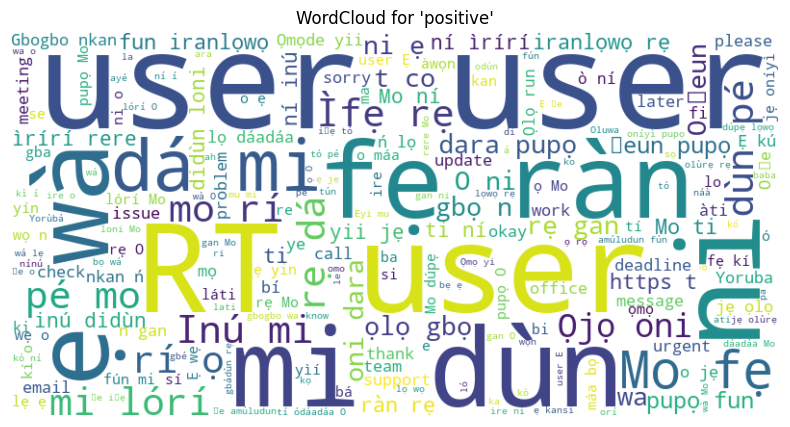

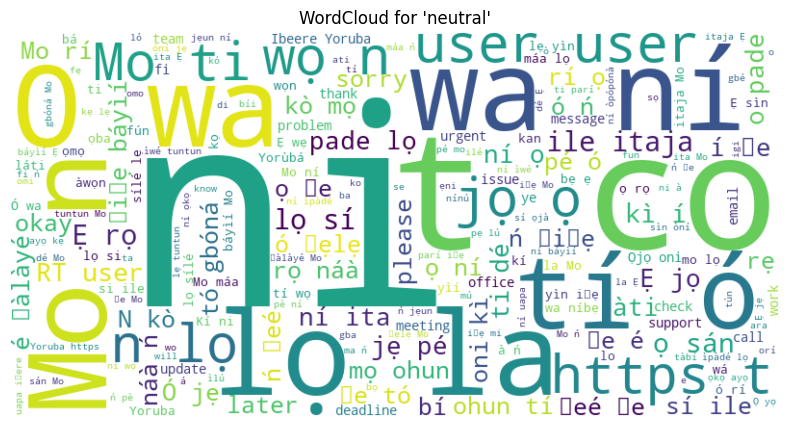

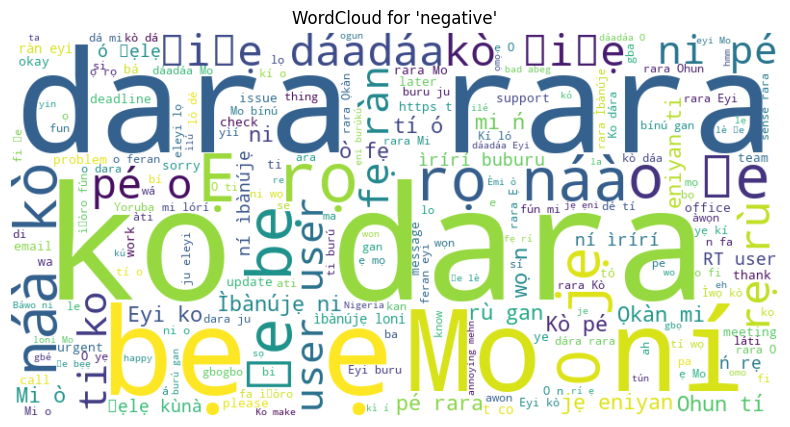

In [ ]:
for label in yor_df["label"].unique():
    text = " ".join(yor_df[yor_df["label"] == label]["tweet"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"WordCloud for '{label}'")
    plt.axis("off")
    plt.show()

In [ ]:
# yorsw = pd.read_csv('yor.csv')
# def preprocess_text(text):
#     if not isinstance(text, str) or not text.strip():
#         return ""
    
#     text = re.sub(r'http\S+|@\w+|#\w+|\bRT\b|"{2,}', '', text, flags=re.IGNORECASE)
#     text = re.sub(r'[.]{2,}', ' ', text)
#     text = re.sub(r'[\!\?\:\.\,]+', ' ', text)
#     text = re.sub(r'\s+', ' ', text).strip()

#     doc = nlp(text)
#     tokens = [
#         token.text.lower() for token in doc 
#         if token.text.lower() not in yorsw.word
#         and token.text not in en_sw
#         and token.text not in string.punctuation
#         and len(token.text.strip()) > 1
#         and not token.text.isdigit()
#     ]

#     return " ".join(tokens).strip() or "empty"

In [ ]:
# yor_df['clean_text'] = yor_df.tweet.apply(preprocess_text)

In [ ]:
# for label in yor_df["label"].unique():
#     text = " ".join(yor_df[yor_df["label"] == label]["clean_text"])
#     wc = WordCloud(width=800, height=400, background_color="white").generate(text)

#     plt.figure(figsize=(10, 5))
#     plt.imshow(wc, interpolation='bilinear')
#     plt.title(f"WordCloud for '{label}'")
#     plt.axis("off")
#     plt.show()

In [ ]:
yor_df.label.value_counts()

label
positive    14700
neutral     13824
negative    11603
Name: count, dtype: int64

<Axes: ylabel='count'>

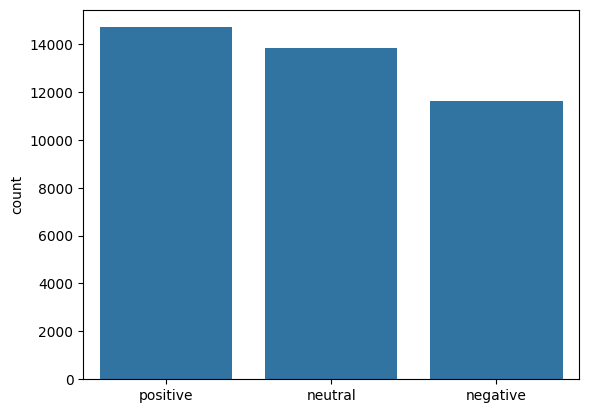

In [ ]:
seaborn.countplot(x=yor_df.label.values)

In [ ]:
labels = {'negative' : 0, 'neutral' : 1, 'positive' : 2}

yor_df['label'] = yor_df.label.map(labels)
yor_df.head()

,tweet,label
0,Bae you try gan.,2
1,Mo gbádùn rẹ.,2
2,O ṣeun gan ni o.,2
3,Ẹ ṣe o.,2
4,Ìfẹ́ rẹ̀ dá mi lórí.,2


In [ ]:
count_positive,count_neutral,count_negative = yor_df.label.value_counts()

In [ ]:
df_class_negative = yor_df[yor_df['label']== 0] 
df_class_positive = yor_df[yor_df['label']== 2]
df_class_neutral = yor_df[yor_df['label']== 1]

In [ ]:
# df_class_worry_over = df_class_negative.sample(count_neutral, replace=True)
df_class_neutral_over = df_class_neutral.sample(count_positive, replace=True)
df_class_negative_over = df_class_negative.sample(count_positive, replace=True)

oversampled_data = pd.concat([df_class_neutral_over, df_class_negative_over, df_class_positive])
print(oversampled_data.label.value_counts())

label
1    14700
0    14700
2    14700
Name: count, dtype: int64


In [ ]:

oversampled_data.head()

,tweet,label
7619,RT @user: @user @user e lo wo fiimu naa ke le ...,1
24599,Mo ní ìwé tuntun.,1
6922,"Bí mo bá sọ̀ nínú ọkọ̀ akérò BRT, n ò kí ń wọ ...",1
33881,O wa ní ita. Mo rí problem meeting sorry Ẹ̀rọ ...,1
9833,ÀWỌN FÌLÀ YORÙBÁ (1): FÌLÀ ÀDÌRỌ - àtúnṣe oge ...,1


- Word2vec

In [ ]:
# def tokenize(text):
#     return str(text).lower().split()

# sentences = [tokenize(t) for t in oversampled_data['clean_text'].astype(str).tolist()]

# w2v_size = 100
# w2v_model = Word2Vec(
#     sentences,
#     vector_size=w2v_size,
#     window=5,
#     min_count=1,  
#     workers=4,
#     sg=1 
# )

# w2v_model.save("yoruba_word2vec.model")

In [ ]:

# def sentence_vector(sentence, model, size):
#     tokens = tokenize(sentence)
#     vecs = []
#     for t in tokens:
#         if t in model.wv:
#             vecs.append(model.wv[t])
#     if len(vecs) == 0:
#         return np.zeros(size, dtype=np.float32)
#     return np.mean(vecs, axis=0)

In [ ]:
# x = np.vstack([sentence_vector(t, w2v_model, w2v_size) for t in oversampled_data['clean_text'].astype(str).tolist()])
# y = oversampled_data['new_label'].astype(int).values

In [ ]:
# print("X shape:", x.shape, "y shape:", y.shape)

In [ ]:
# x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y)

In [ ]:
train_df, test_df = train_test_split(oversampled_data, test_size=0.2, random_state=42, stratify=oversampled_data["label"])

In [ ]:
# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
train_dataset

Dataset({
    features: ['tweet', 'label', '__index_level_0__'],
    num_rows: 35280
})

In [ ]:
# AfriSenti tokenizer (handles Yoruba diacritics/code-switching better than your custom one)
tokenizer = AutoTokenizer.from_pretrained("Davlan/afrisenti-twitter-sentiment-afroxlmr-large")

def preprocess_function(examples):
    return tokenizer(examples["tweet"], truncation=True, padding="max_length", max_length=128)  # Adjust max_length if needed

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 8820/8820 [00:28<00:00, 306.29 examples/s]


In [ ]:
# Load AfriSenti model
model = AutoModelForSequenceClassification.from_pretrained(
    "Davlan/afrisenti-twitter-sentiment-afroxlmr-large", num_labels=3
)

In [ ]:
# Metrics (weighted F1, like your classification_report)
f1_metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels, average="weighted")

In [ ]:
# Training args (tune as needed)
training_args = TrainingArguments(
    output_dir="./afrisenti_results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

In [ ]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,  # Use test as eval for simplicity; swap to a dev split if you have one
    compute_metrics=compute_metrics,
)

: 

In [ ]:
# Fine-tune
trainer.train()

# Savee
# trainer.save_model("./fine_tuned_afrisenti")

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
# AfriSenti predictions
predictions = trainer.predict(tokenized_test)
afrisenti_preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids
label_names = ["negative", "neutral", "positive"]
print("AfriSenti Classification Report:")
print(classification_report(true_labels, afrisenti_preds, target_names=label_names, digits=4))

In [ ]:
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [ ]:
# ran_model = RandomForestClassifier(n_estimators=200, random_state=42)
# ran_model.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# rand_ypred = ran_model.predict(x_test)

# print(classification_report(y_test, rand_ypred))

              precision    recall  f1-score   support

           0       0.97      0.92      0.95      2940
           1       0.92      0.93      0.93      2940
           2       0.90      0.93      0.92      2940

    accuracy                           0.93      8820
   macro avg       0.93      0.93      0.93      8820
weighted avg       0.93      0.93      0.93      8820



In [ ]:
# f1 = f1_score(y_test, rand_ypred, average='weighted')
# precision = precision_score(y_test, rand_ypred, average='weighted')
# recall = recall_score(y_test, rand_ypred, average='weighted')
# accuracy = accuracy_score(y_test, rand_ypred)

# print("Rand Forest Classifier Model Evaluation")
# print("Accuracy score:", "{:.2f}".format(round(accuracy, 2)))
# print("F1 score:", "{:.2f}".format(round(f1, 2)))
# print("Precision score:", "{:.2f}".format(round(precision, 2)))
# print("Recall score:", "{:.2f}".format(round(recall, 2)))

In [ ]:
# # 1. Tokenize & pad sequences
# texts = oversampled_data['clean_text'].tolist()
# labels = oversampled_data['new_label'].values

# # Parameters
# max_vocab_size = 10000
# max_seq_length = 50  # adjust based on sentence length distribution
# embedding_dim = 100
# num_classes = len(np.unique(labels))

# tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
# tokenizer.fit_on_texts(texts)
# sequences = tokenizer.texts_to_sequences(texts)
# padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post', truncating='post')

# # Convert labels to one-hot
# labels_cat = to_categorical(labels, num_classes=num_classes)

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels_cat, test_size=0.2, random_state=42, stratify=labels)

In [ ]:
# # --- BiLSTM Model ---
# def create_bilstm_model():
#     model = Sequential([
#         Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
#         Bidirectional(LSTM(64, return_sequences=False)),
#         Dropout(0.5),
#         Dense(64, activation='relu'),
#         Dropout(0.5),
#         Dense(num_classes, activation='softmax')
#     ])
#     model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#     return model

# # --- CNN Model ---
# def create_cnn_model():
#     model = Sequential([
#         Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
#         Conv1D(filters=128, kernel_size=5, activation='relu'),
#         GlobalMaxPooling1D(),
#         Dense(64, activation='relu'),
#         Dropout(0.5),
#         Dense(num_classes, activation='softmax')
#     ])
#     model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#     return model

In [ ]:
# # Choose model to train
# model = create_bilstm_model()
# # Train
# history = model.fit(
#     X_train, y_train,
#     epochs=10,
#     batch_size=64,
#     validation_split=0.1,
#     verbose=1
# )

# # Evaluate
# loss, accuracy = model.evaluate(X_test, y_test)
# print(f"Test accuracy: {accuracy:.4f}")

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 189s 342ms/step - accuracy: 0.8176 - loss: 0.4351 - val_accuracy: 0.9036 - val_loss: 0.2650
Epoch 2/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 136s 273ms/step - accuracy: 0.9316 - loss: 0.1887 - val_accuracy: 0.9104 - val_loss: 0.2411
Epoch 3/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 149s 299ms/step - accuracy: 0.9575 - loss: 0.1235 - val_accuracy: 0.9206 - val_loss: 0.2470
Epoch 4/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 189s 272ms/step - accuracy: 0.9695 - loss: 0.0875 - val_accuracy: 0.9229 - val_loss: 0.2808
Epoch 5/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 143s 274ms/step - accuracy: 0.9781 - loss: 0.0656 - val_accuracy: 0.9289 - val_loss: 0.3509
Epoch 6/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 145s 279ms/step - accuracy: 0.9831 - loss: 0.0513 - val_accuracy: 0.9235 - val_loss: 0.4043
Epoch 7/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 138s 270ms/step - accuracy: 0.9862 - loss: 0.0436 - val_accuracy: 0.9269 - val_loss: 0.4705
Epoch 8/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 143s 270ms/step - accuracy: 0.9869 -

In [ ]:
# model2 = create_cnn_model()

# # Train
# history = model2.fit(
#     X_train, y_train,
#     epochs=10,
#     batch_size=64,
#     validation_split=0.1,
#     verbose=1
# )

# # Evaluate
# loss, accuracy = model2.evaluate(X_test, y_test)
# print(f"Test accuracy: {accuracy:.4f}")

Epoch 1/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 95s 174ms/step - accuracy: 0.8502 - loss: 0.3793 - val_accuracy: 0.9155 - val_loss: 0.2144
Epoch 2/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 143s 177ms/step - accuracy: 0.9540 - loss: 0.1346 - val_accuracy: 0.9280 - val_loss: 0.2037
Epoch 3/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 163s 219ms/step - accuracy: 0.9820 - loss: 0.0595 - val_accuracy: 0.9286 - val_loss: 0.2462
Epoch 4/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 145s 291ms/step - accuracy: 0.9915 - loss: 0.0300 - val_accuracy: 0.9297 - val_loss: 0.2772
Epoch 5/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 156s 197ms/step - accuracy: 0.9954 - loss: 0.0197 - val_accuracy: 0.9311 - val_loss: 0.3181
Epoch 6/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 145s 201ms/step - accuracy: 0.9973 - loss: 0.0114 - val_accuracy: 0.9314 - val_loss: 0.3505
Epoch 7/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 140s 197ms/step - accuracy: 0.9976 - loss: 0.0117 - val_accuracy: 0.9221 - val_loss: 0.3731
Epoch 8/10
497/497 ━━━━━━━━━━━━━━━━━━━━ 146s 204ms/step - accuracy: 0.9977 - 

In [ ]:
# def text_to_w2v_vector(text, w2v_model):
#     words = text.split()  # or use same tokenizer/cleaning as training
#     words = [w for w in words if w in w2v_model.wv]
#     if not words:
#         return np.zeros(w2v_model.vector_size)
#     return np.mean(w2v_model.wv[words], axis=0)

# samples = [
#     "O ṣeun pupọ fun iranlọwọ rẹ.",   # Positive
#     "O jẹ eniyan ti ko dara rara.",     # Negative
#     "Mo n lọ si ile itaja.",           # Neutral
#     "Ìfẹ́ rẹ̀ dá mi lórí.",            # Positive
#     "Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.",       # Negative
#     "Ọjọ́ oni dara pupọ.",           # Positive
#     "Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.",      # Negative
#     "Mo máa lọ sílé lẹ́yìn iṣẹ́.",    # Neutral
#     "Inú mi dùn pé mo rí ọ.",          # Positive
#     "O yẹ kí o dara ju eleyi lọ.",     # Negative
#     "A o pade lọ́la.",
#     "Eyi kò dáa.",
#     "O wa ní ita.",
#     "Eyi ko ye mi.",
#     "Mo fẹ́ràn rẹ gan-an.",
#     "Mi o feran eyi.",
#     "Eyi ko dara rara.",
#     "O ṣeun gan ni o.",
#     "Ọjọ́ oni dara pupọ.",
#     "Mo ti dé.",
#     "O ni ẹ̀wà.",
#     "O dara rara ni.",
#     "Kò pé rara.",
#     "Mo fe ki o maa wa.",
#     "O wa ní uapa iṣere.",

#     # ---- additional stress-test samples (20) ----
#     "Mo fẹ́ràn ẹ.",  # Short positive
#     "Kò dáa.",        # Short negative
#     "Mo ti dé.",      # Short neutral
#     "Inú mi dùn gidigidi pé mo rí ọ lónìí, o jẹ́ ẹni tí o ní inú rere ati ọwọ́ gidi.",  # Long positive
#     "Kò pé rara, ìṣe rẹ̀ ti fà ìṣòro fún gbogbo wa ati pe a nilo atunṣe lẹ́sẹ̀kẹsẹ̀.",     # Long negative
#     "Lónìí ni mo lọ sí ọjà, rà ẹran, ewa, ati ata, mo sì pada lọ sílé mi.",            # Long neutral
#     "Today was so lit! Inú mi dùn púpọ̀ gan-an.",                                       # Code-switch positive
#     "That movie no make sense rara, kò dáa lójú mi.",                                   # Code-switch negative
#     "Mo wà ni office right now, lásìkò ìsinmi.",                                       # Code-switch neutral
#     "Ó ṣeé ṣe kó dáa ju béẹ lọ, ṣùgbọ́n a máa gba béẹ ni.",                             # Sarcastic-ish / ambiguous
#     "Wow, ìyẹn dáa gan… *smh*.",                                                         # Sarcastic negative
#     "Ṣé ìwọ máa wà níbi iṣẹ́ lọ́la?",                                                   # Question neutral
#     "Mo fẹ́ràn rẹ gan-an! 😍🔥",                                                         # Positive w/ emojis
#     "Kò dáa rara ooo!!! 😡💔",                                                           # Negative w/ emojis
#     "Mo wà ní ilé oooo 😂😂",                                                            # Neutral w/ emojis
#     "Ní ọ̀sẹ̀ tó kọjá, mo lọ sí ìpàdé àtàwọn ọ̀rẹ́ mi, a jẹun, a rẹ́rìn-ín, gbogbo ẹ̀ dá mi lórí.",  # Story positive
#     "Mo gbìmọ̀ sí iṣẹ́ tuntun, ṣùgbọ́n ohun gbogbo baje lẹ́yìn ọjọ́ méjì, kò ní ìtọ́nisọ́nà kankan.", # Story negative
#     "Ní òwúrọ̀, mo jí, mo ṣe àdúrà, mo jẹun, mo sì lọ sí iṣẹ́.",                                  # Story neutral
#     "This vibe sweet die, ìgbádùn gan ni!",                                                  # Code-switch slang positive
#     "Na wah o, ìrìnàjò yìí tire mehn, kò dáa kankan."                                          # Code-switch slang negative
# ]

# models = {
#     "RandomForest": ran_model,
#     "MLP": mlp_model,
#     "XGBoost": xgb_model
# }

# label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

# def dl_predict(model, texts):
#     seqs = tokenizer.texts_to_sequences(texts)
#     padded = tf.keras.preprocessing.sequence.pad_sequences(
#         seqs, maxlen=max_seq_length, padding='post', truncating='post'
#     )
#     preds = model.predict(padded, verbose=0)
#     classes = np.argmax(preds, axis=1)
#     return [label_map[c] for c in classes]

# for text in samples:
#     print(f"\n{text}")

#     # ML model predictions (Word2Vec embeddings)
#     vec = text_to_w2v_vector(text, w2v_model).reshape(1, -1)
#     for name, clf in models.items():
#         pred_idx = clf.predict(vec)[0]
#         pred_label = label_map.get(pred_idx, pred_idx)
#         print(f"  {name} -> {pred_label}")

#     # DL model predictions
#     for name, dl_model in [("BiLSTM", model), ("CNN", model2)]:
#         pred_label = dl_predict(dl_model, [text])[0]
#         print(f"  {name} -> {pred_label}")


O ṣeun pupọ fun iranlọwọ rẹ.
  RandomForest -> positive
  MLP -> positive
  XGBoost -> positive
  BiLSTM -> positive
  CNN -> positive

O jẹ eniyan ti ko dara rara.
  RandomForest -> negative
  MLP -> negative
  XGBoost -> negative
  BiLSTM -> negative
  CNN -> negative

Mo n lọ si ile itaja.
  RandomForest -> neutral
  MLP -> positive
  XGBoost -> neutral
  BiLSTM -> neutral
  CNN -> neutral

Ìfẹ́ rẹ̀ dá mi lórí.
  RandomForest -> positive
  MLP -> positive
  XGBoost -> positive
  BiLSTM -> positive
  CNN -> positive

Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.
  RandomForest -> negative
  MLP -> negative
  XGBoost -> negative
  BiLSTM -> negative
  CNN -> negative

Ọjọ́ oni dara pupọ.
  RandomForest -> positive
  MLP -> positive
  XGBoost -> positive
  BiLSTM -> positive
  CNN -> positive

Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.
  RandomForest -> negative
  MLP -> negative
  XGBoost -> negative
  BiLSTM -> negative
  CNN -> negative

Mo máa lọ sílé lẹ́yìn iṣẹ́.
  RandomForest -> neutral
  MLP -> positive
  XGBoost

In [ ]:
# from transformers import pipeline

# # Load the sentiment model (it handles Yoruba out-of-the-box)
# classifier = pipeline("sentiment-analysis", model="Davlan/afrisenti-twitter-sentiment-afroxlmr-large")

# # Example predictions on your samples
# sample = ["Mo fẹ́ràn rẹ gan-an.", "Eyi ko dara rara.", "Mo n lọ si ile itaja."]
# preds = classifier(samples)
# print(preds)  # Outputs like [{'label': 'positive', 'score': 0.95}, ...]

Error while downloading from https://cdn-lfs-us-1.hf.co/repos/b7/93/b7930932f533515d0736a1ad4c9c96f58221f0a4431dea636af506a6c1eba9d5/8c41d64e8f6f4aabdcddbfe2b5ed480db85d3933f00eb86c67bf7d85d059db7c?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27pytorch_model.bin%3B+filename%3D%22pytorch_model.bin%22%3B&response-content-type=application%2Foctet-stream&Expires=1755007416&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc1NTAwNzQxNn19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zL2I3LzkzL2I3OTMwOTMyZjUzMzUxNWQwNzM2YTFhZDRjOWM5NmY1ODIyMWYwYTQ0MzFkZWE2MzZhZjUwNmE2YzFlYmE5ZDUvOGM0MWQ2NGU4ZjZmNGFhYmRjZGRiZmUyYjVlZDQ4MGRiODVkMzkzM2YwMGViODZjNjdiZjdkODVkMDU5ZGI3Yz9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomcmVzcG9uc2UtY29udGVudC10eXBlPSoifV19&Signature=FrAX%7EqmqpQzu3C1n6W-DLtNMddCTUpQcNam4LcBsRjj8K1DtYHXd9LbjjI%7EyKiqei4UXY5IDArmkVgJKwh1QIfww9TGxpQn3-hfWg5UXD6b0io-7WQA8FZCvVO%7EXC%7EJKwKQ3TLjYJOjpgMmsJuNm4Kmb31RWR6XLC7jz2dnWuYM

[{'label': 'positive', 'score': 0.9986445307731628}, {'label': 'negative', 'score': 0.9977214932441711}, {'label': 'neutral', 'score': 0.9948391318321228}]


Error while downloading from https://cdn-lfs-us-1.hf.co/repos/b7/93/b7930932f533515d0736a1ad4c9c96f58221f0a4431dea636af506a6c1eba9d5/a274372a9131f8463f588e408292c3b8f0b0295e10129eefe69392346c0542de?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27model.safetensors%3B+filename%3D%22model.safetensors%22%3B&Expires=1755008123&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc1NTAwODEyM319LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zL2I3LzkzL2I3OTMwOTMyZjUzMzUxNWQwNzM2YTFhZDRjOWM5NmY1ODIyMWYwYTQ0MzFkZWE2MzZhZjUwNmE2YzFlYmE5ZDUvYTI3NDM3MmE5MTMxZjg0NjNmNTg4ZTQwODI5MmMzYjhmMGIwMjk1ZTEwMTI5ZWVmZTY5MzkyMzQ2YzA1NDJkZT9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSoifV19&Signature=XTA0mdiu2sgs5cjLGlwFGu27xEdabO7rj8GmREX7ZYHtGZTRKXNYAWCzN6X5m55gV2%7Emch8LVo9baehqe3pknK0V6GFaptsOfyjXIBKLYboRFrNY9feykoyAo03gRCT2gW2Yuf56cM2vHlOHpjCGfFo0bM5w8KoLgB3DTMu9XXJaY1Ov9ymMI1A2eL64YB5iAGPDHIKejal8n0L-LzygrTzee2SopWVE0sCWqgWsW-drqLkLKJgMYp8zijrhaPq4Ql

In [ ]:
# samps = [
#     "O ṣeun pupọ fun iranlọwọ rẹ.",   # Positive
#     "O jẹ eniyan ti ko dara rara.",     # Negative
#     "Mo n lọ si ile itaja.",           # Neutral
#     "Ìfẹ́ rẹ̀ dá mi lórí.",            # Positive
#     "Ìbànújẹ ni pé o ṣe bẹ́ẹ̀.",       # Negative
#     "Ọjọ́ oni dara pupọ.",           # Positive
#     "Ẹ̀rọ náà kò ṣiṣẹ́ dáadáa.",      # Negative
#     "Mo máa lọ sílé lẹ́yìn iṣẹ́.",    # Neutral
#     "Inú mi dùn pé mo rí ọ.",          # Positive
#     "O yẹ kí o dara ju eleyi lọ.",     # Negative
#     "A o pade lọ́la.",
#     "Eyi kò dáa.",
#     "O wa ní ita.",
#     "Eyi ko ye mi.",
#     "Mo fẹ́ràn rẹ gan-an.",
#     "Mi o feran eyi.",
#     "Eyi ko dara rara.",
#     "O ṣeun gan ni o.",
#     "Ọjọ́ oni dara pupọ.",
#     "Mo ti dé.",
#     "O ni ẹ̀wà.",
#     "O dara rara ni.",
#     "Kò pé rara.",
#     "Mo fe ki o maa wa.",
#     "O wa ní uapa iṣere.",

#     # ---- additional stress-test samples (20) ----
#     "Mo fẹ́ràn ẹ.",  # Short positive
#     "Kò dáa.",        # Short negative
#     "Mo ti dé.",      # Short neutral
#     "Inú mi dùn gidigidi pé mo rí ọ lónìí, o jẹ́ ẹni tí o ní inú rere ati ọwọ́ gidi.",  # Long positive
#     "Kò pé rara, ìṣe rẹ̀ ti fà ìṣòro fún gbogbo wa ati pe a nilo atunṣe lẹ́sẹ̀kẹsẹ̀.",     # Long negative
#     "Lónìí ni mo lọ sí ọjà, rà ẹran, ewa, ati ata, mo sì pada lọ sílé mi.",            # Long neutral
#     "Today was so lit! Inú mi dùn púpọ̀ gan-an.",                                       # Code-switch positive
#     "That movie no make sense rara, kò dáa lójú mi.",                                   # Code-switch negative
#     "Mo wà ni office right now, lásìkò ìsinmi.",                                       # Code-switch neutral
#     "Ó ṣeé ṣe kó dáa ju béẹ lọ, ṣùgbọ́n a máa gba béẹ ni.",                             # Sarcastic-ish / ambiguous
#     "Wow, ìyẹn dáa gan… *smh*.",                                                         # Sarcastic negative
#     "Ṣé ìwọ máa wà níbi iṣẹ́ lọ́la?",                                                   # Question neutral
#     "Mo fẹ́ràn rẹ gan-an! 😍🔥",                                                         # Positive w/ emojis
#     "Kò dáa rara ooo!!! 😡💔",                                                           # Negative w/ emojis
#     "Mo wà ní ilé oooo 😂😂",                                                            # Neutral w/ emojis
#     "Ní ọ̀sẹ̀ tó kọjá, mo lọ sí ìpàdé àtàwọn ọ̀rẹ́ mi, a jẹun, a rẹ́rìn-ín, gbogbo ẹ̀ dá mi lórí.",  # Story positive
#     "Mo gbìmọ̀ sí iṣẹ́ tuntun, ṣùgbọ́n ohun gbogbo baje lẹ́yìn ọjọ́ méjì, kò ní ìtọ́nisọ́nà kankan.", # Story negative
#     "Ní òwúrọ̀, mo jí, mo ṣe àdúrà, mo jẹun, mo sì lọ sí iṣẹ́.",                                  # Story neutral
#     "This vibe sweet die, ìgbádùn gan ni!",                                                  # Code-switch slang positive
#     "Na wah o, ìrìnàjò yìí tire mehn, kò dáa kankan."                                          # Code-switch slang negative
# ]
# predss = classifier(samps)
# print(predss)

[{'label': 'positive', 'score': 0.9980117082595825}, {'label': 'negative', 'score': 0.9974924325942993}, {'label': 'neutral', 'score': 0.9948391318321228}, {'label': 'positive', 'score': 0.9982104301452637}, {'label': 'negative', 'score': 0.9014191031455994}, {'label': 'positive', 'score': 0.9993283748626709}, {'label': 'negative', 'score': 0.9884169697761536}, {'label': 'neutral', 'score': 0.9900471568107605}, {'label': 'positive', 'score': 0.9995896220207214}, {'label': 'neutral', 'score': 0.7325330376625061}, {'label': 'positive', 'score': 0.7319777607917786}, {'label': 'negative', 'score': 0.5988377332687378}, {'label': 'neutral', 'score': 0.9411308765411377}, {'label': 'positive', 'score': 0.9372619390487671}, {'label': 'positive', 'score': 0.9986445307731628}, {'label': 'positive', 'score': 0.9933714866638184}, {'label': 'negative', 'score': 0.9977214932441711}, {'label': 'positive', 'score': 0.999301552772522}, {'label': 'positive', 'score': 0.9993283748626709}, {'label': 'posit